In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True


In [18]:
d = 200
gamma_1 = 0.5
gamma_2 = 0.5
k1 = int(gamma_1*d)
k2 = int(gamma_2*d)
Delta = 0.2
v = np.mean(np.sort(np.random.randn(10000, k2), axis=1), axis=0)

alpha = 3.75
nsample = 100
m = 36
vmin, vmax = -2, 2

In [19]:
A = [[[] for _ in range(m)] for _ in range(m)]
G = np.linspace(vmin, vmax, m+1)


for i in range(nsample):
    W2a = np.loadtxt(f'alpha_{alpha}_v2/W2a_{i+1}.csv', delimiter=',')
    W20 = np.loadtxt(f'alpha_{alpha}_v2/W20_{i+1}.csv', delimiter=',')
    v2 = v.T@W2a/np.sqrt(k2)
    W2a = W2a[np.argsort(v)][:, np.argsort(v2)]
    W20 = W20[np.argsort(v)][:, np.argsort(v2)]
    v2=np.sort(v2)

    i = np.digitize(v, G) - 1
    j = np.digitize(v2, G) - 1
    for a in range(len(v)):
        for b in range(len(v2)):
            if 0 <= i[a] < m and 0 <= j[b] < m:
                A[i[a]][j[b]].append( [W2a[a, b], W20[a, b]] )

result = np.zeros((m,m))
for i in range(m):
    for j in range(m):
        if len(A[i][j])>0:
            w1, w2  = np.array(A[i][j]).T
            result[i,j] = np.sum(w1*w2)/( np.sqrt( np.sum(w1**2)*np.sum(w2**2) ) )

Text(0.5, 1.0, '$\\alpha=3.75$')

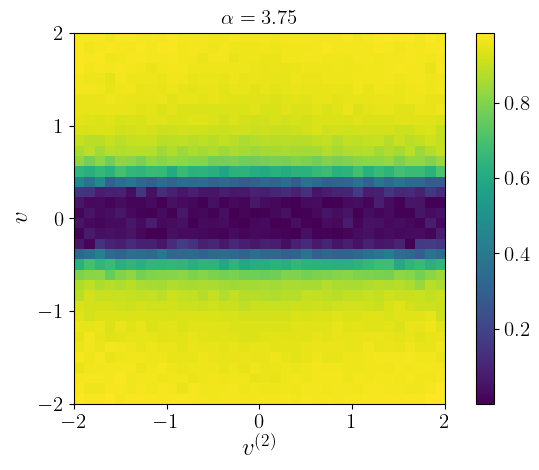

In [20]:
size=15
fig, ax = plt.subplots(tight_layout=True)
im = ax.imshow(np.abs(result), origin='lower', extent=[vmin, vmax, vmin, vmax])
ax.set_xticks(np.linspace(vmin, vmax, 5))
ax.set_yticks(np.linspace(vmin, vmax, 5))
ax.tick_params(axis='x', labelsize=size)
ax.tick_params(axis='y', labelsize=size)
ax.set_xlabel(r'$v^{(2)}$', fontsize=int(1.2*size))
ax.set_ylabel(r'$v$', fontsize=int(1.2*size))

cbar = fig.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=size)
plt.title(fr'$\alpha={alpha}$', fontsize=size)
# plt.savefig(f'Q2heatmap_numerical_{alpha}.pdf')
# plt.show()